In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as mticker

import config, plotting
from dimelo import parse_bam, plot_enrichment, load_processed
from utils import track

In [7]:
lmnb1_bam_file = config.processed_data_dir / "barcode24.bam"

cLAD = {
    "bed_file": config.processed_data_dir / "cLAD_gold_final_250kb.t2t_chm13v2.bed",
    "motif": "A,0",
    "id": "cLADs",
}
ciLAD = {
    "bed_file": config.processed_data_dir / "ciLAD_gold_final_250kb.t2t_chm13v2.bed",
    "motif": "A,0",
    "id": "ciLADs"
}
on_target_accessibility = {
    "bed_file": config.processed_data_dir / "gm12878_accessibility.on_target.bed",
    "motif": "GCH,1",
    "id": "active TSSs"
}
off_target_accessibility = {
    "bed_file": config.processed_data_dir / "gm12878_accessibility.off_target.bed",
    "motif": "GCH,1",
    "id": "active TSS\nflanking regions"
}
on_target_CG = {
    "bed_file": config.processed_data_dir / "gm12878_cpg.on_target.bed",
    "motif": "WCG,1",
    "id": "inactive TSS\nCpG islands"
}
off_target_CG = {
    "bed_file": config.processed_data_dir / "gm12878_cpg.off_target.bed",
    "motif": "WCG,1",
    "id": "active TSS\nCpG islands"
}
condition_dicts = [cLAD, ciLAD, on_target_accessibility, off_target_accessibility, on_target_CG, off_target_CG]
A_dicts = [cLAD, ciLAD]
GC_dicts = [on_target_accessibility, off_target_accessibility]
CG_dicts = [on_target_CG, off_target_CG]
on_target_dicts = [cLAD, on_target_accessibility, on_target_CG]
off_target_dicts = [ciLAD, off_target_accessibility, off_target_CG]

In [8]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"

mod_prob_thresh = 0.75
n_cores = 10

In [4]:
for condition_dict in condition_dicts:
    output_id = ".".join([lmnb1_bam_file.stem, condition_dict['bed_file'].stem])
    with track(f"pileup.{output_id}", log_path="perf.jsonl"):
        parse_bam.pileup(
            input_file=lmnb1_bam_file,
            output_name=f"pileup.{output_id}",
            output_directory=config.processed_data_dir,
            ref_genome=reference_file,
            regions=condition_dict["bed_file"],
            motifs=[condition_dict["motif"]],
            thresh=mod_prob_thresh,
            window_size=None,
            cores=n_cores,
            override_checks=True,
        )
    with track(f"extract.{output_id}", log_path="perf.jsonl"):
        parse_bam.extract(
            input_file=lmnb1_bam_file,
            output_name=f"extract.{output_id}",
            ref_genome=reference_file,
            output_directory=config.processed_data_dir,
            regions=condition_dict["bed_file"],
            motifs=[condition_dict["motif"]],
            thresh=None, # No thresholding at extract time
            window_size=None,
            cores=n_cores,
            override_checks=True,
        )

Please verify that barcode24.bam is actually aligned to chm13v2.0.fa.
Allocating requested 10 cores.
Modification threshold of 0.75 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode24.bam   0% | 00:00<?

          |    0%

[perf] pileup.barcode24.cLAD_gold_final_250kb.t2t_chm13v2: 417.2s  peak 34.47 GB
Please verify that barcode24.bam is actually aligned to chm13v2.0.fa.
Allocating requested 10 cores.
No valid base modification threshold provided. Raw probs will be saved.


...

          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in barcode24.bam   0% | 00:00<?

          |    0%

          | Transferring 15786 from reads.WCG,1.txt into reads.combined_basemods.h5, new size 15786   0% | 00:…

[perf] extract.barcode24.gm12878_cpg.off_target: 59.6s  peak 6.53 GB


# Main text figures

[perf] plot_enrichment.barcode24.main_text: 76.7s  peak 2.72 GB


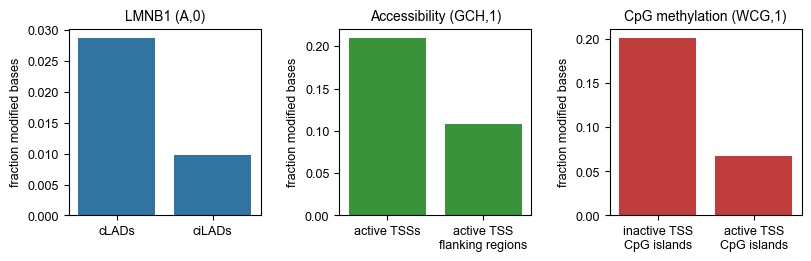

In [9]:
fig, axes = plt.subplots(1, 3, layout="constrained", figsize=(8, 2.5))

with track(f"plot_enrichment.{lmnb1_bam_file.stem}.main_text", log_path="perf.jsonl"):
    plot_enrichment.plot_enrichment(
        mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in A_dicts],
        regions_list=[condition_dict["bed_file"] for condition_dict in A_dicts],
        motifs=[condition_dict["motif"] for condition_dict in A_dicts],
        sample_names=[condition_dict["id"] for condition_dict in A_dicts],
        palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in A_dicts},
        quiet=True,
        ax=axes[0]
    )
    axes[0].set_title("LMNB1 (A,0)")
    plot_enrichment.plot_enrichment(
        mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in GC_dicts],
        regions_list=[condition_dict["bed_file"] for condition_dict in GC_dicts],
        motifs=[condition_dict["motif"] for condition_dict in GC_dicts],
        sample_names=[condition_dict["id"] for condition_dict in GC_dicts],
        palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in GC_dicts},
        quiet=True,
        ax=axes[1]
    )
    axes[1].set_title("Accessibility (GCH,1)")
    plot_enrichment.plot_enrichment(
        mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in CG_dicts],
        regions_list=[condition_dict["bed_file"] for condition_dict in CG_dicts],
        motifs=[condition_dict["motif"] for condition_dict in CG_dicts],
        sample_names=[condition_dict["id"] for condition_dict in CG_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in CG_dicts},
    quiet=True,
    ax=axes[2]
    )
    axes[2].set_title("CpG methylation (WCG,1)")

plt.savefig(config.figure_dir / "lmnb1.plot_enrichment.svg")
plt.show()
plt.close()

# Supplemental Figures

In [10]:
rng = np.random.default_rng()
mod_event_sample_size = 200000  # subsetting mod events to save on time and memory

In [13]:
with track(f"read_vectors_from_hdf5.{lmnb1_bam_file.stem}.on_target", log_path="perf.jsonl"):
    on_target_motif_mod_vector_dict = {}
    for condition_dict in on_target_dicts:
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=config.processed_data_dir / f"extract.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "reads.combined_basemods.h5",
            motifs=[condition_dict["motif"]],
            regions=condition_dict["bed_file"],
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        on_target_motif_mod_vector_dict[condition_dict["motif"]] = rng.choice(mod_vector, mod_event_sample_size)

[perf] read_vectors_from_hdf5.barcode24.on_target: 35.3s  peak 5.66 GB


In [14]:
with track(f"read_vectors_from_hdf5.{lmnb1_bam_file.stem}.off_target", log_path="perf.jsonl"):
    off_target_motif_mod_vector_dict = {}
    for condition_dict in off_target_dicts:
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=config.processed_data_dir / f"extract.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "reads.combined_basemods.h5",
            motifs=[condition_dict["motif"]],
            regions=condition_dict["bed_file"],
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        off_target_motif_mod_vector_dict[condition_dict["motif"]] = rng.choice(mod_vector, mod_event_sample_size)

[perf] read_vectors_from_hdf5.barcode24.off_target: 48.4s  peak 6.17 GB


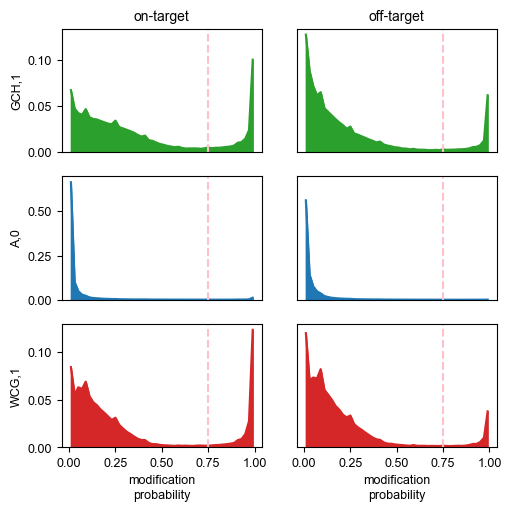

In [15]:
motifs = ["GCH,1", "A,0", "WCG,1"]
targets = ["on-target", "off-target"]
target_keys = ["on", "off"]
target_dicts = [on_target_motif_mod_vector_dict, off_target_motif_mod_vector_dict]

# shared PMF grid over the modification-probability range [0, 1]
pmf_bins = np.linspace(0, 1, 51)
pmf_centers = 0.5 * (pmf_bins[:-1] + pmf_bins[1:])

def to_pmf(vec):
    counts, _ = np.histogram(vec, bins=pmf_bins)
    total = counts.sum()
    return counts / total if total else counts

# rows = motifs, columns = on-target | off-target
mosaic = [[f"{motif}:on", f"{motif}:off"] for motif in motifs]
fig, axs_dict = plt.subplot_mosaic(mosaic, layout="constrained", figsize=(5, 5))

for motif_idx, motif in enumerate(motifs):
    color = plotting.default_palette_map[motif]
    vecs = [target_dicts[t][motif] for t in range(2)]
    pmfs = [to_pmf(v) for v in vecs]

    for i, target in enumerate(targets):
        ax = axs_dict[f"{motif}:{target_keys[i]}"]
        sns.lineplot(x=pmf_centers, y=pmfs[i], ax=ax, color=color)
        ax.fill_between(pmf_centers, pmfs[i], color=color)
        if motif_idx == 0:
            ax.set_title(target)
        if motif_idx != len(motifs) - 1:
            ax.set_xticks([])
        else:
            ax.set_xlabel("modification\nprobability")
        if i == 0:
            ax.set_ylabel(motif)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
        else:
            ax.set_yticks([])
        ax.axvline(mod_prob_thresh, linestyle="--", color="pink")

    # Shared y limits across the on/off pair
    row_axes = [axs_dict[f"{motif}:{k}"] for k in target_keys]
    row_ymax = max(pmfs[0].max(), pmfs[1].max())
    for ax in row_axes:
        ax.set_ylim(0, row_ymax * 1.05)

plt.savefig(config.figure_dir / "lmnb1.mod_probs.on_vs_off_target.svg", bbox_inches="tight")
plt.show()
plt.close()